In [10]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [11]:
##S3_BUCKET = "s3://ads508-housing-data-faye"

S3_BUCKET = "sagemaker-studio-mru71pwhjb"
DATA_PATH = f"s3://{S3_BUCKET}/prepared/full_prepared_dataset.csv"

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df.shape)
df.head()

(48300, 17)


,RegionID,SizeRank,RegionName,RegionType,StateName,Date,ZHVI,Inventory,MarketTemp,MedianSalePrice,Year,Month,ZHVI_Lag1,Inventory_Lag1,MarketTemp_Lag1,ZHVI_PctChange,Inventory_PctChange
0,394299,251,"Abilene, TX",msa,TX,2009-04-30,107899.903735,856.0,42.0,224318.333333,2009,4,107910.504329,856.0,42.0,-0.000098,0.0
1,394299,251,"Abilene, TX",msa,TX,2009-05-31,107974.321882,856.0,42.0,224318.333333,2009,5,107899.903735,856.0,42.0,0.000690,0.0
2,394299,251,"Abilene, TX",msa,TX,2009-06-30,107888.771914,856.0,42.0,224318.333333,2009,6,107974.321882,856.0,42.0,-0.000792,0.0
3,394299,251,"Abilene, TX",msa,TX,2009-07-31,107865.541887,856.0,42.0,224318.333333,2009,7,107888.771914,856.0,42.0,-0.000215,0.0
4,394299,251,"Abilene, TX",msa,TX,2009-08-31,107831.584511,856.0,42.0,224318.333333,2009,8,107865.541887,856.0,42.0,-0.000315,0.0


In [12]:
target = "MedianSalePrice"

features = [
    "Year", "Month", "Inventory", "MarketTemp", "ZHVI",
    "ZHVI_Lag1", "Inventory_Lag1", "MarketTemp_Lag1",
    "ZHVI_PctChange", "Inventory_PctChange", "StateName"
]

df_model = df[features + [target]].dropna().copy()

X = df_model[features]
y = df_model[target]

print(X.shape, y.shape)

(48300, 11) (48300,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(38640, 11) (9660, 11)


In [14]:
numeric_features = [
    "Year", "Month", "Inventory", "MarketTemp", "ZHVI",
    "ZHVI_Lag1", "Inventory_Lag1", "MarketTemp_Lag1",
    "ZHVI_PctChange", "Inventory_PctChange"
]

categorical_features = ["StateName"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

In [15]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
preds = model.predict(X_test)

rmse = math.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")
print(f"R²: {r2:.4f}")

RMSE: 18,126.06
MAE: 12,104.09
R²: 0.9853


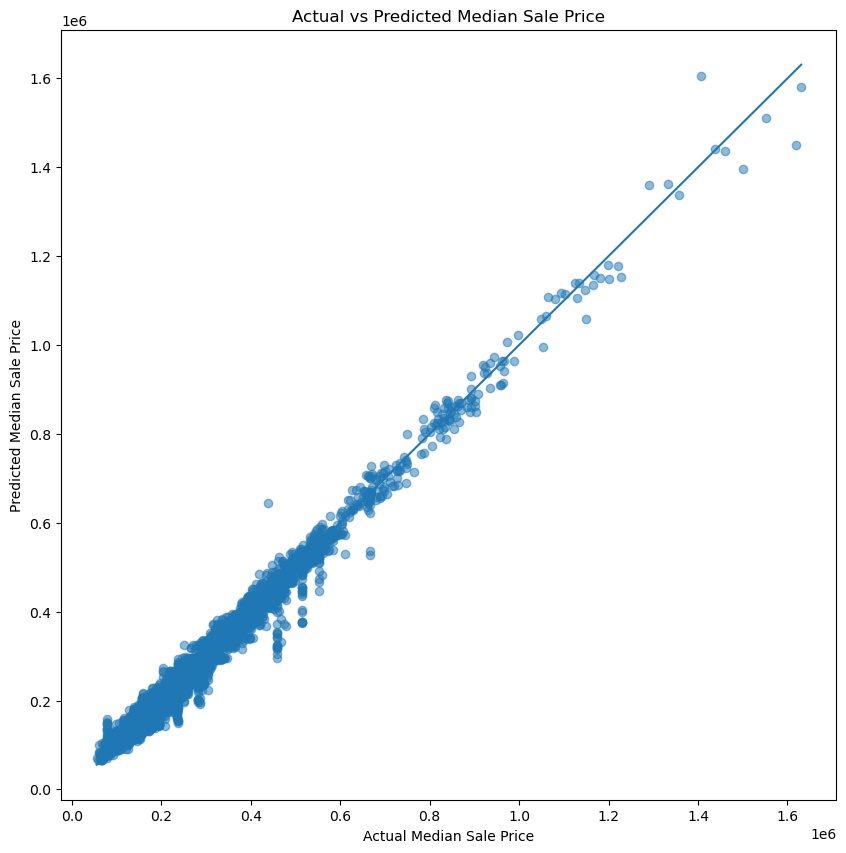

In [17]:
plt.figure(figsize=(10, 10))
plt.scatter(y_test, preds, alpha=0.5)
plt.xlabel("Actual Median Sale Price")
plt.ylabel("Predicted Median Sale Price")
plt.title("Actual vs Predicted Median Sale Price")

min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

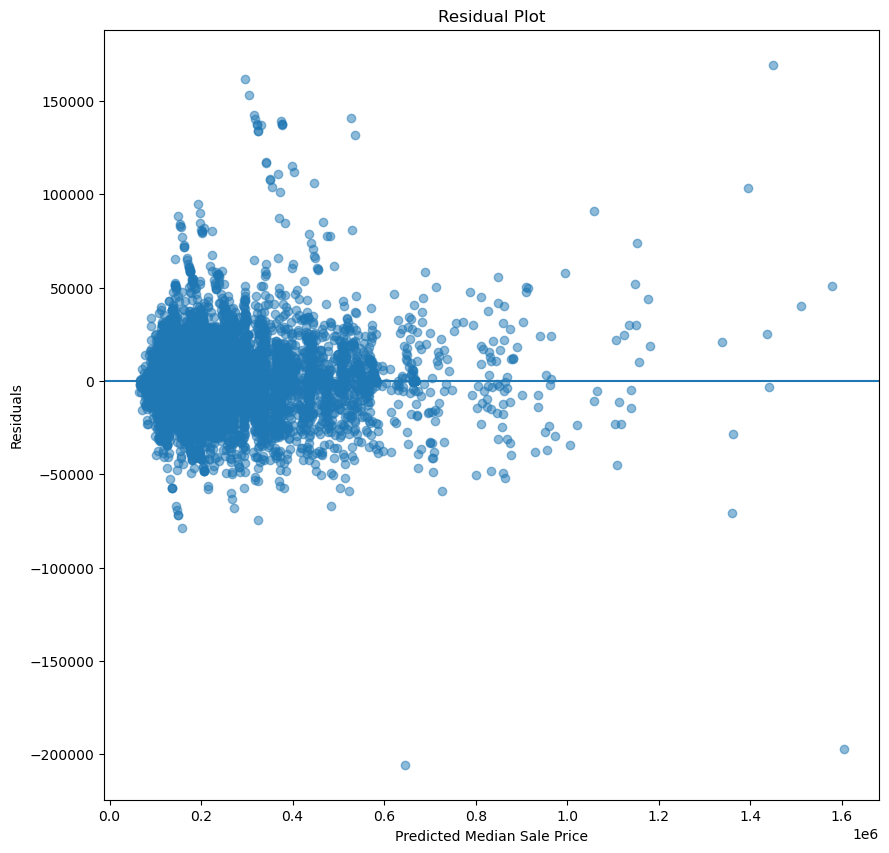

In [18]:
#Residual Plot
residuals = y_test - preds

plt.figure(figsize=(10, 10))
plt.scatter(preds, residuals, alpha=0.5)
plt.axhline(y=0)
plt.xlabel("Predicted Median Sale Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [19]:
rf = model.named_steps["regressor"]
preprocessor_fitted = model.named_steps["preprocessor"]

encoded_cat_names = preprocessor_fitted.named_transformers_["cat"]\
    .named_steps["onehot"].get_feature_names_out(categorical_features)

feature_names = numeric_features + list(encoded_cat_names)
importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
4,ZHVI,0.778991
5,ZHVI_Lag1,0.053905
42,StateName_OR,0.033365
0,Year,0.029134
3,MarketTemp,0.021676
7,MarketTemp_Lag1,0.017520
6,Inventory_Lag1,0.015717
2,Inventory,0.012489
37,StateName_NM,0.011866
35,StateName_NC,0.005380


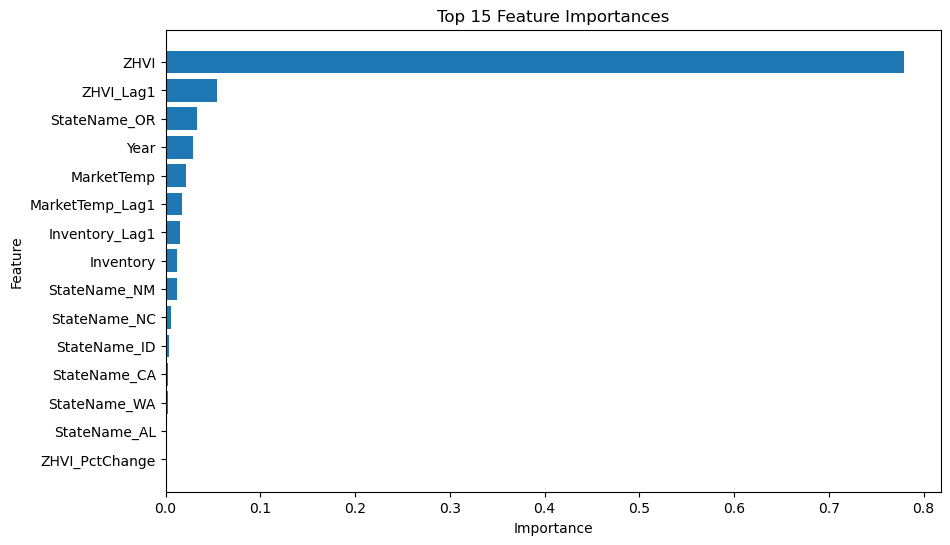

In [20]:
top_features = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")
plt.show()